In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression

from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import r2_score, accuracy_score
from sklearn.model_selection import StratifiedGroupKFold

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
DATA_DIR = "../data"
JOINT_PATH = os.path.join(DATA_DIR, "joint_county_year_2018_2019.csv")

TRAIN_CASTHMA_PATH = os.path.join(DATA_DIR, "train_CASTHMA.csv")
TEST_CASTHMA_PATH = os.path.join(DATA_DIR, "test_CASTHMA.csv")

TRAIN_COPD_PATH = os.path.join(DATA_DIR, "train_COPD.csv")
TEST_COPD_PATH = os.path.join(DATA_DIR, "test_COPD.csv")
RANDOM_STATE = 42

In [3]:
copd_train = pd.read_csv(TRAIN_COPD_PATH)
copd_test = pd.read_csv(TEST_COPD_PATH)
casthma_train = pd.read_csv(TRAIN_CASTHMA_PATH)
casthma_test = pd.read_csv(TEST_CASTHMA_PATH)

In [4]:
features_full = casthma_train.columns[3:-2]

In [5]:
# ── Binary rurality ──────────────────────────────────────
# 0 = urban (NCHS 1–4), 1 = rural (NCHS 5–6)
copd_train['rural_binary'] = (copd_train['nchs_urban_rural'] >= 5).astype(int)
copd_test['rural_binary'] = (copd_test['nchs_urban_rural'] >= 5).astype(int)
casthma_train['rural_binary'] = (casthma_train['nchs_urban_rural'] >= 5).astype(int)
casthma_test['rural_binary'] = (casthma_test['nchs_urban_rural'] >= 5).astype(int)

C:\Users\Xaalthe71\AppData\Local\Temp\ipykernel_9516\3224118479.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  copd_train['rural_binary'] = (copd_train['nchs_urban_rural'] >= 5).astype(int)
C:\Users\Xaalthe71\AppData\Local\Temp\ipykernel_9516\3224118479.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  copd_test['rural_binary'] = (copd_test['nchs_urban_rural'] >= 5).astype(int)
C:\Users\Xaalthe71\AppData\Local\Temp\ipykernel_9516\3224118479.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

In [6]:
DEMO_COLS = [
    'population','median_age','median_income',
    'pct_white','pct_black','pct_asian','pct_hispanic',
    'rural_binary']
HEALTH_CONFOUNDER_COLS = ['CSMOKING','OBESITY','DIABETES']
CROPLAND_COLS = ['cropland_diversity','county_crop_concentration','pct_cropland']
OTHER_COLS = ['YEAR']

BASE_COLS = DEMO_COLS + HEALTH_CONFOUNDER_COLS + CROPLAND_COLS + OTHER_COLS

In [7]:
features2 = features_full.drop(['NAME','COPD', 'CASTHMA'])
features3 =features2.drop(casthma_train.isnull().sum().iloc[casthma_train.isnull().sum().to_numpy().nonzero()].index) #drop nan columns

In [8]:
features3[:-1]

Index(['pesticide_total_kg', 'pesticide_anilide_kg', 'pesticide_carbamate_kg',
       'pesticide_chlorophenoxy_kg', 'pesticide_organochlorine_kg',
       'pesticide_organophosphate_kg', 'pesticide_other_kg',
       'pesticide_pyrethroid_kg', 'pesticide_triazine_kg',
       'pesticide_respiratory_kg',
       ...
       'cropland_acres', 'total_area_acres', 'pct_cropland', 'corn_acres',
       'soybean_acres', 'cotton_acres', 'wheat_acres', 'hay_acres',
       'fruit_veg_acres', 'rice_acres'],
      dtype='str', length=466)

# Asthma

In [27]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=10,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=casthma_train.cat3_CASTHMA # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=casthma_train[['FIPS','CASTHMA']] # don't need full data for this one
groups=casthma_train.FIPS # using county index as groups

rmse_full = []
rmse_base = []
resid_base = []
resid_full =[]
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    casthma_val = casthma_train.iloc[val_index,:]
    casthma_tt = casthma_train.iloc[train_index,:]


    y_tt = casthma_tt.CASTHMA
    x_tt = casthma_tt[features3]

    x_val = casthma_val[features3]
    y_val = casthma_val.CASTHMA

    y_tt_base = casthma_tt.CASTHMA
    x_tt_base = casthma_tt[BASE_COLS]

    x_val_base = casthma_val[BASE_COLS]
    y_val_base = casthma_val.CASTHMA

    model_base = XGBRegressor()
    model_base.fit(x_tt_base, y_tt_base)

    pred_base = model_base.predict(x_val_base)
    rmse_base.append(rmse(y_val_base, pred_base))
    resid_base.append(abs(y_val-pred_base))

    model1 = XGBRegressor()
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_full.append(rmse(y_val, pred1))
    resid_full.append(abs(y_val-pred1))
    


In [10]:
print(rmse_full)

[0.379189045589525, 0.4055198064611168, 0.36979735645844575, 0.363373367484703, 0.34972777034113967, 0.3817029646482822, 0.3298271466303295, 0.3402873667772922, 0.41951052736898825, 0.3460653633593854]


In [19]:
print(rmse_base)

[0.5139542054425038, 0.5482252230810108, 0.4710424939522535, 0.5152255721285052, 0.508622793529599, 0.4941897677931308, 0.4637300376353147, 0.516611531187409, 0.525756593655597, 0.47103139517873643]


In [22]:
wilcoxon(rmse_base, rmse_full)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.001953125))

In [11]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=10,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=casthma_train.cat3_CASTHMA # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=casthma_train[['FIPS','CASTHMA']] # don't need full data for this one
groups=casthma_train.FIPS # using county index as groups

rmse_base = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    casthma_val = casthma_train.iloc[val_index,:]
    casthma_tt = casthma_train.iloc[train_index,:]


    y_tt = casthma_tt.CASTHMA
    x_tt = casthma_tt[BASE_COLS]

    x_val = casthma_val[BASE_COLS]
    y_val = casthma_val.CASTHMA

    model1 = XGBRegressor()
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_base.append(rmse(y_val, pred1))

In [12]:
print(rmse_base)

[0.5139542054425038, 0.5482252230810108, 0.4710424939522535, 0.5152255721285052, 0.508622793529599, 0.4941897677931308, 0.4637300376353147, 0.516611531187409, 0.525756593655597, 0.47103139517873643]


Seems like the pesticides are at least doing something

In [ ]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=4,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=casthma_train.cat3_CASTHMA # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=casthma_train[['FIPS','CASTHMA']] # don't need full data for this one
groups=casthma_train.FIPS # using county index as groups


# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    if i==0:
        break
casthma_val = casthma_train.iloc[val_index,:]
casthma_tt = casthma_train.iloc[train_index,:]

y_tt = casthma_tt.CASTHMA
x_tt = casthma_tt[BASE_COLS]

x_val = casthma_val[BASE_COLS]
y_val = casthma_val.CASTHMA

y_tt_full = casthma_tt.CASTHMA
x_tt_full = casthma_tt[features3]

y_val_full = casthma_val.CASTHMA
x_val_full = casthma_val[features3]

In [43]:
model_base = XGBRegressor()
model_full = XGBRegressor()
model_full.fit(x_tt_full, y_tt_full)
model_base.fit(x_tt, y_tt)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [44]:
print(rmse(y_val, model_base.predict(x_val)))
print(rmse(y_val_full, model_full.predict(x_val_full)))

0.5021423016990773
0.3875078182326667


In [45]:
model_full.feature_importances_.argsort()

array([299, 301, 302, 306,   4,  15,  17, 309, 318, 312, 313, 315, 321,
       316, 292, 291,  56,  57, 294, 295, 296,  47,  49,  51,  66,  65,
        62,  63, 426, 423, 422, 420, 280, 333, 335, 336, 427, 428, 433,
       434,  73,  69,  70,  72, 323,  74, 326, 331,  77, 282, 283,  76,
       338, 275, 277, 278,  82,  79, 409, 405,  97,  94,  89,  86, 137,
       256, 267, 264, 269, 273, 410, 412, 413, 414,  99, 101, 102, 103,
       105, 108, 109, 110, 111, 113, 115, 119, 122, 124, 248, 125, 126,
       127, 251, 250, 252, 254, 150, 138, 396, 400, 402, 132, 129, 274,
       389, 390, 387, 388, 391, 392, 395, 394, 152, 151, 140, 149, 155,
       136, 135, 376, 375, 374, 371, 162, 161, 160, 159, 156,  32,  30,
        34,  44,  20, 440, 442,  36,  39, 378, 380, 382, 383, 386, 165,
       168, 169, 172, 176, 177, 178, 180, 181, 183, 187, 189, 340, 341,
       344, 343, 348, 350, 218, 353, 243, 192, 359, 355, 360, 362, 198,
       364, 367, 197, 222, 221, 224, 223, 219, 209, 229, 232, 23

<BarContainer object of 12 artists>

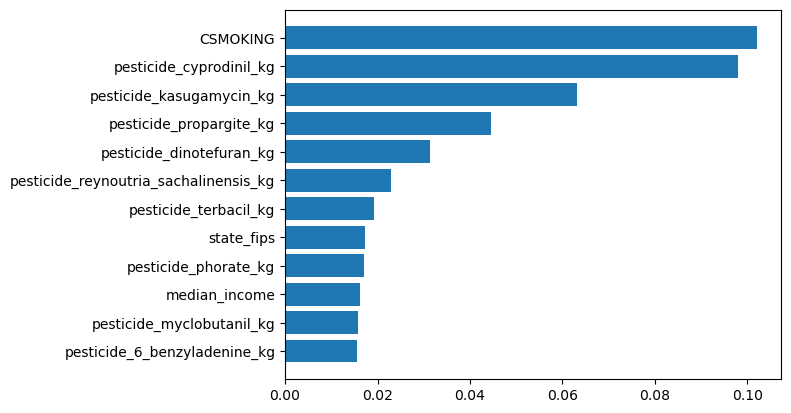

In [67]:
plt.barh(x_val_full.columns[[13, 293, 447, 324, 455, 407, 372, 153, 345, 255, 121, 452]], width=model_full.feature_importances_[[13, 293, 447, 324, 455, 407, 372, 153, 345, 255, 121, 452]])

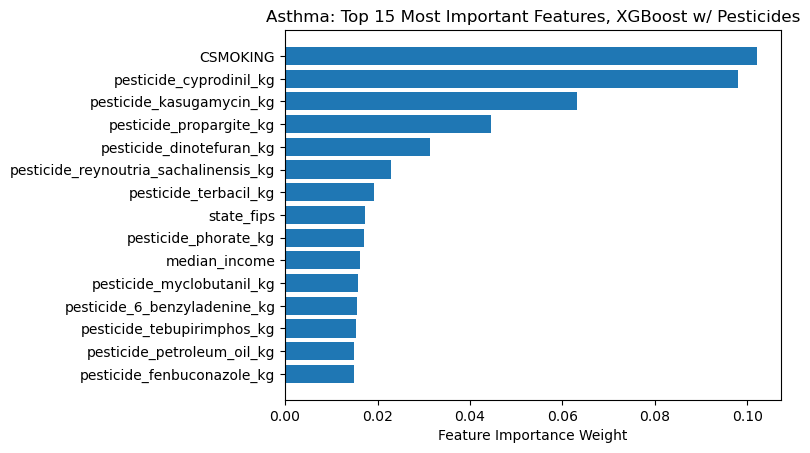

In [89]:
plt.barh(x_val_full.columns[model_full.feature_importances_.argsort()[-15:]], width=model_full.feature_importances_[model_full.feature_importances_.argsort()[-15:]])
plt.title("Asthma: Top 15 Most Important Features, XGBoost w/ Pesticides")
plt.xlabel('Feature Importance Weight')
plt.show()

In [78]:
model_full.feature_importances_.sum()

np.float32(0.99999994)

In [46]:
x_val_full.columns[[13, 293, 447, 324, 455, 407, 372, 153, 345, 255, 121, 452]]

Index(['pesticide_6_benzyladenine_kg', 'pesticide_myclobutanil_kg',
       'median_income', 'pesticide_phorate_kg', 'state_fips',
       'pesticide_terbacil_kg', 'pesticide_reynoutria_sachalinensis_kg',
       'pesticide_dinotefuran_kg', 'pesticide_propargite_kg',
       'pesticide_kasugamycin_kg', 'pesticide_cyprodinil_kg', 'CSMOKING'],
      dtype='str')

In [47]:
model_base.feature_importances_.argsort()

array([ 7,  9,  1,  5,  0, 12, 14,  3,  4, 10,  2, 13,  6, 11,  8])

In [ ]:
x_val.columns[model_base.feature_importances_.argsort()]

Index(['rural_binary', 'OBESITY', 'median_age', 'pct_asian', 'population',
       'county_crop_concentration', 'YEAR', 'pct_white', 'pct_black',
       'DIABETES', 'median_income', 'pct_cropland', 'pct_hispanic',
       'cropland_diversity', 'CSMOKING'],
      dtype='str')

In [71]:
len(model_base.feature_importances_.argsort()[-15:])

15

In [70]:
len(x_val.columns)

15

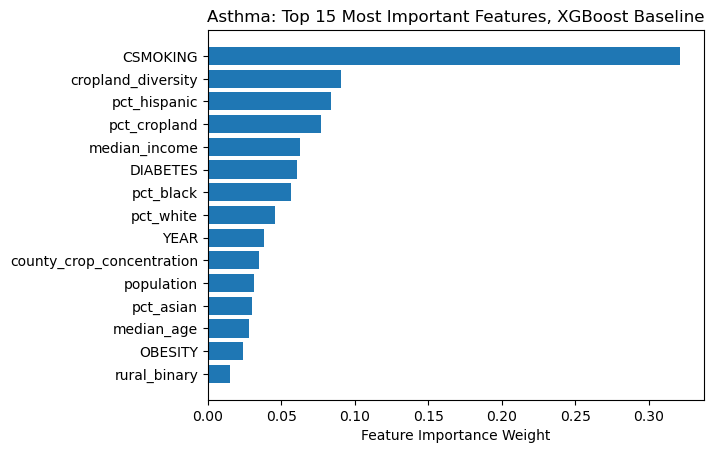

In [88]:
plt.barh(x_val.columns[model_base.feature_importances_.argsort()], width=model_base.feature_importances_[model_base.feature_importances_.argsort()])
plt.title("Asthma: Top 15 Most Important Features, XGBoost Baseline")
plt.xlabel('Feature Importance Weight')
plt.show()

In [82]:
model_base.get_booster().get_score(importance_type='gain')

{'population': 0.5330013036727905,
 'median_age': 0.47956761717796326,
 'median_income': 1.066861867904663,
 'pct_white': 0.7741488814353943,
 'pct_black': 0.9651626944541931,
 'pct_asian': 0.5099983215332031,
 'pct_hispanic': 1.4245469570159912,
 'rural_binary': 0.25622424483299255,
 'CSMOKING': 5.46826696395874,
 'OBESITY': 0.40688297152519226,
 'DIABETES': 1.0264803171157837,
 'cropland_diversity': 1.5459257364273071,
 'county_crop_concentration': 0.5931704044342041,
 'pct_cropland': 1.3095276355743408,
 'YEAR': 0.6507044434547424}

smoking is still the greatest predictor but pesticides are the top 6 out of 7

In [14]:
from scipy.stats import wilcoxon

In [15]:
wilcoxon(rmse_base, rmse_full)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.001953125))

In [16]:
np.mean(rmse_full)

np.float64(0.36850007151192077)

In [17]:
np.mean(rmse_base)

np.float64(0.5028389613584061)

# COPD

In [28]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=10,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=copd_train.cat3_COPD# the class we want to stratify on - in this case the categorical labels for COPD
X=copd_train[['FIPS','COPD']] # don't need full data for this one
groups=copd_train.FIPS # using county index as groups

rmse_full_copd = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    copd_val = copd_train.iloc[val_index,:]
    copd_tt = copd_train.iloc[train_index,:]


    y_tt = copd_tt.COPD
    x_tt = copd_tt[features3]

    x_val = copd_val[features3]
    y_val = copd_val.COPD

    model1 = XGBRegressor()
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_full_copd.append(rmse(y_val, pred1))

In [29]:
rmse_full_copd

[0.786220448624269,
 0.7300488071705724,
 0.7712973054423674,
 0.7435867198373269,
 0.704420574950817,
 0.8231315190263309,
 0.6983918060913562,
 0.8329145638472387,
 0.740108990901334,
 0.7838463030228475]

In [30]:
np.mean(rmse_full_copd)

np.float64(0.761396703891446)

In [31]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=10,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=copd_train.cat3_COPD # the class we want to stratify on - in this case the categorical labels for COPD
X=copd_train[['FIPS','COPD']] # don't need full data for this one
groups=copd_train.FIPS # using county index as groups

rmse_base_copd = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    copd_val = copd_train.iloc[val_index,:]
    copd_tt = copd_train.iloc[train_index,:]


    y_tt = copd_tt.COPD
    x_tt = copd_tt[BASE_COLS]

    x_val = copd_val[BASE_COLS]
    y_val = copd_val.COPD

    model1 = XGBRegressor()
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_base_copd.append(rmse(y_val, pred1))

In [32]:
rmse_base_copd

[0.7939370525054852,
 0.8078828446122005,
 0.8217887002083698,
 0.7908610030972166,
 0.782589413654276,
 0.8750799017087434,
 0.787649300040412,
 0.8699909240122523,
 0.7748225506737626,
 0.7983725406236981]

In [33]:
np.mean(rmse_base_copd)

np.float64(0.8102974231136416)

In [34]:
wilcoxon(rmse_full_copd, rmse_base_copd) #this seems like it doesn't work since I have the same p-value for very different datasets.

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.001953125))

In [ ]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=4,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=copd_train.cat3_CASTHMA # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=casthma_train[['FIPS','CASTHMA']] # don't need full data for this one
groups=casthma_train.FIPS # using county index as groups


# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    if i==0:
        break
casthma_val = casthma_train.iloc[val_index,:]
casthma_tt = casthma_train.iloc[train_index,:]

y_tt = casthma_tt.CASTHMA
x_tt = casthma_tt[BASE_COLS]

x_val = casthma_val[BASE_COLS]
y_val = casthma_val.CASTHMA

y_tt_full = casthma_tt.CASTHMA
x_tt_full = casthma_tt[features3]

y_val_full = casthma_val.CASTHMA
x_val_full = casthma_val[features3]

In [16]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=10,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=copd_train.cat3_COPD # the class we want to stratify on - in this case the categorical labels for COPD
X=copd_train[['FIPS','COPD']] # don't need full data for this one
groups=copd_train.FIPS # using county index as groups

rmse_base_copd = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    if i ==0:
        break
copd_val = copd_train.iloc[val_index,:]
copd_tt = copd_train.iloc[train_index,:]


y_tt = copd_tt.COPD
x_tt = copd_tt[BASE_COLS]

x_val = copd_val[BASE_COLS]
y_val = copd_val.COPD

y_tt_full= copd_tt.COPD
x_tt_full = copd_tt[features3]

x_val_full = copd_val[features3]
y_val_full = copd_val.COPD


In [17]:
model_base = XGBRegressor()
model_full = XGBRegressor()
model_full.fit(x_tt_full, y_tt_full)
model_base.fit(x_tt, y_tt)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


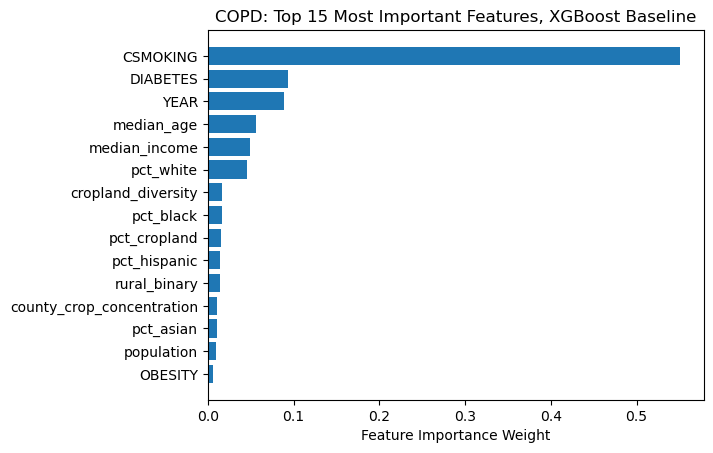

In [18]:
plt.barh(x_val.columns[model_base.feature_importances_.argsort()], width=model_base.feature_importances_[model_base.feature_importances_.argsort()])
plt.title("COPD: Top 15 Most Important Features, XGBoost Baseline")
plt.xlabel('Feature Importance Weight')
plt.show()

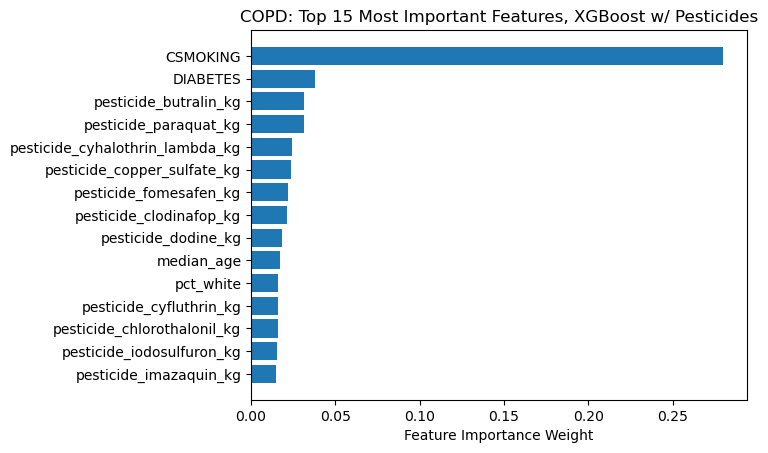

In [ ]:
plt.barh(x_val_full.columns[model_full.feature_importances_.argsort()[-15:]], width=model_full.feature_importances_[model_full.feature_importances_.argsort()[-15:]])
plt.title("COPD: Top 15 Most Important Features, XGBoost w/ Pesticides")
plt.xlabel('Feature Importance Weight')
plt.show()